In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\devso\causal-ml-project\data\raw\hillstrom.csv")

# treatment
df['treatment'] = df['segment'].apply(lambda x: 0 if x == 'No E-Mail' else 1)

# drop leakage columns
df = df.drop(columns=['segment', 'visit', 'spend'])

# one-hot encoding
df = pd.get_dummies(df, drop_first=True)

df.head()

,recency,history,mens,womens,newbie,conversion,treatment,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +",zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.44,1,0,0,0,1,True,False,False,False,False,False,True,False,True,False
1,6,329.08,1,1,1,0,0,False,True,False,False,False,False,False,False,False,True
2,7,180.65,0,1,1,0,1,True,False,False,False,False,False,True,False,False,True
3,9,675.83,1,0,1,0,1,False,False,False,True,False,False,False,False,False,True
4,2,45.34,1,0,0,0,1,False,False,False,False,False,False,False,True,False,True


In [2]:
X = df.drop(columns=['conversion', 'treatment'])
T = df['treatment']
Y = df['conversion']

In [3]:
from sklearn.linear_model import LogisticRegression

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, T)

propensity_scores = ps_model.predict_proba(X)[:,1]

df['propensity_score'] = propensity_scores

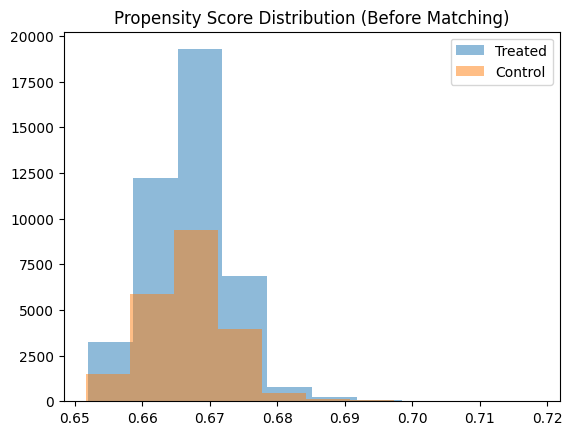

In [4]:
import matplotlib.pyplot as plt

plt.hist(df[df['treatment']==1]['propensity_score'], alpha=0.5, label='Treated')
plt.hist(df[df['treatment']==0]['propensity_score'], alpha=0.5, label='Control')
plt.legend()
plt.title("Propensity Score Distribution (Before Matching)")
plt.show()

In [5]:
from sklearn.neighbors import NearestNeighbors

treated = df[df['treatment']==1]
control = df[df['treatment']==0]

# fit nearest neighbor on control
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])

matched_control = control.iloc[indices.flatten()]
matched_treated = treated.reset_index(drop=True)

In [6]:
matched_df = pd.concat([matched_treated, matched_control], axis=0)

In [7]:
matched_df.groupby('treatment')[['recency', 'history']].mean()

,recency,history
treatment,,
0,5.803766,237.546412
1,5.770741,242.686002


In [8]:
ate = (
    matched_treated['conversion'].mean() -
    matched_control['conversion'].mean()
)

print("Estimated ATE:", ate)

Estimated ATE: 0.005480863821614277
